# 模様解析の基礎：画像を数値で測る

対応章: [`../chapters/04_reaction_diffusion_snake.md`](../chapters/04_reaction_diffusion_snake.md)

人工画像だけを使って特徴量の意味と限界を学ぶ。実際のヘビ画像との比較、損失関数、パラメータ探索は卒業研究として残す。

## 1. ライブラリ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

## 2. 正解を目で確認できる人工模様を作る

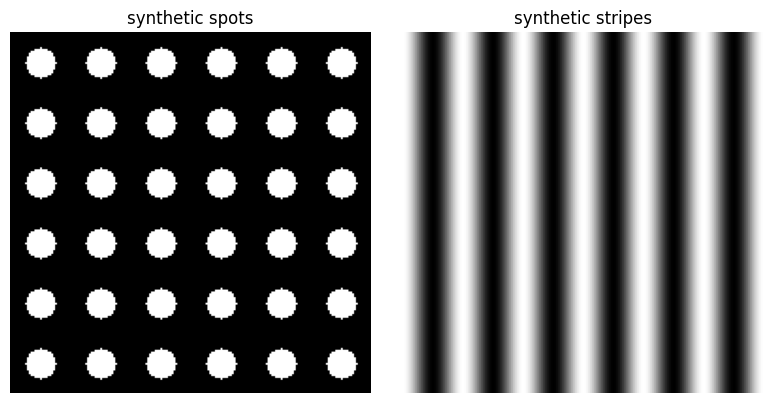

In [2]:
def make_spots(size=192, spacing=32, radius=8):
    yy, xx = np.mgrid[:size, :size]
    image = np.zeros((size, size), dtype=float)
    for cy in range(spacing // 2, size, spacing):
        for cx in range(spacing // 2, size, spacing):
            image[(xx - cx)**2 + (yy - cy)**2 <= radius**2] = 1.0
    return image

def make_stripes(size=192, wavelength=32):
    x = np.arange(size)
    row = 0.5 + 0.5 * np.cos(2 * np.pi * x / wavelength)
    return np.tile(row, (size, 1))

spots = make_spots()
stripes = make_stripes()
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, image, title in zip(axes, [spots, stripes], ['synthetic spots', 'synthetic stripes']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 3. 面積比・連結成分数・特徴波長

特徴量を1つずつ返す。複数特徴量をまとめた距離や損失関数はまだ作らない。

In [3]:
def area_fraction(image, threshold=0.5):
    return np.mean(image >= threshold)

def component_count(image, threshold=0.5, connectivity=8):
    binary = image >= threshold
    structure = ndimage.generate_binary_structure(2, 1 if connectivity == 4 else 2)
    _, count = ndimage.label(binary, structure=structure)
    return count

def dominant_wavelength(image):
    centered = image - image.mean()
    power = np.abs(np.fft.fftshift(np.fft.fft2(centered)))**2
    size = image.shape[0]
    yy, xx = np.mgrid[:size, :size]
    radius = np.sqrt((xx - size//2)**2 + (yy - size//2)**2).astype(int)
    radial_power = np.bincount(radius.ravel(), weights=power.ravel())
    radial_count = np.bincount(radius.ravel())
    spectrum = radial_power / np.maximum(radial_count, 1)
    spectrum[:2] = 0.0
    peak_radius = np.argmax(spectrum[:size//2])
    return np.inf if peak_radius == 0 else size / peak_radius

rows = []
for name, image in [('spots', spots), ('stripes', stripes)]:
    rows.append([name, area_fraction(image), component_count(image), dominant_wavelength(image)])
pd.DataFrame(rows, columns=['pattern', 'area fraction', 'components (8-neighbor)', 'dominant wavelength [pixel]'])

,pattern,area fraction,components (8-neighbor),dominant wavelength [pixel]
0,spots,0.192383,36,32.0
1,stripes,0.484375,7,32.0


## 4. 平行移動と閾値への感度を確認する

In [4]:
shifted = np.roll(spots, shift=(3, 5), axis=(0, 1))
rows = []
for threshold in [0.3, 0.5, 0.7]:
    for name, image in [('original', spots), ('shifted', shifted)]:
        rows.append([threshold, name, area_fraction(image, threshold), component_count(image, threshold)])
pd.DataFrame(rows, columns=['threshold', 'image', 'area fraction', 'components'])

,threshold,image,area fraction,components
0,0.3,original,0.192383,36
1,0.3,shifted,0.192383,36
2,0.5,original,0.192383,36
3,0.5,shifted,0.192383,36
4,0.7,original,0.192383,36
5,0.7,shifted,0.192383,36


## 5. Fourierパワースペクトルを観察する

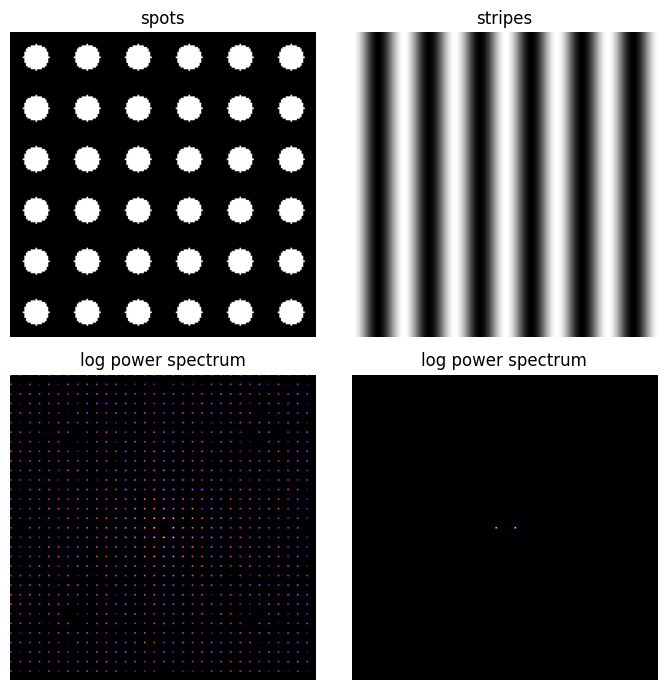

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for col, (name, image) in enumerate([('spots', spots), ('stripes', stripes)]):
    power = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(image - image.mean())))**2)
    axes[0, col].imshow(image, cmap='gray')
    axes[1, col].imshow(power, cmap='magma')
    axes[0, col].set_title(name)
    axes[1, col].set_title('log power spectrum')
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout(); plt.show()

## 6. 課題

1. 面積比が同じで斑点数が異なる2画像を作る。
2. `connectivity=4` と `8` で結果が変わる画像を作る。
3. ノイズを加え、特徴量がどこから不安定になるか調べる。
4. 各特徴量の検証を終えてから研究用Notebookを別に作る。ヘビ画像との距離や最適パラメータは、この教材Notebookには追加しない。